# Wildfire Prediction: Exploratory Data Analysis (EDA)


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Consistent color scheme used across all charts
COLOR_FIRE = "#B85042"
COLOR_NOFIRE = "#5D737E"
COLOR_DAY = "#E8A33D"
COLOR_NIGHT = "#1E2761"


In [ ]:
df = pd.read_csv("final_dataset.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Dataset loaded: 118,858 rows x 17 columns


,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max,occured,frp
0,0.0,-15.19928,38.54393,5.654271,955.608333,136.083333,43.611845,250.333333,15.883333,18.375000,4.89,35.0,23.175000,12.9,13.5,0.0,3.69
1,1.0,31.51203,-101.57546,16.564673,927.016667,181.333333,31.925260,296.916667,10.529167,3.416667,7.24,16.0,29.733333,13.4,16.2,0.0,0.73
2,1.0,-13.74538,28.05493,5.542089,884.379167,109.166667,8.379870,210.958333,6.095833,12.208333,3.68,35.0,14.104167,11.1,16.8,0.0,0.78
3,0.0,13.53091,-11.22573,7.703410,981.158333,168.416667,133.287570,244.208333,13.095833,56.458333,5.59,29.0,26.704167,12.9,11.0,0.0,8.91
4,0.0,5.61833,16.59892,16.895093,917.116667,202.208333,91.791875,266.750000,6.712500,9.166667,6.00,10.0,26.820833,16.0,16.6,0.0,5.97


## 2. Dataset Health Check

Before analyzing any patterns, we verify the raw quality of the data.


### 2.1 Shape & Data Types

In [ ]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print()
print(df.dtypes)


Rows: 118,858
Columns: 17

daynight_N                  float64
lat                         float64
lon                         float64
fire_weather_index          float64
pressure_mean               float64
wind_direction_mean         float64
wind_direction_std          float64
solar_radiation_mean        float64
dewpoint_mean               float64
cloud_cover_mean            float64
evapotranspiration_total    float64
humidity_min                float64
temp_mean                   float64
temp_range                  float64
wind_speed_max              float64
occured                     float64
frp                         float64
dtype: object


### 2.2 Missing Values

In [ ]:
missing = df.isna().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("No missing values across the entire dataset.")
else:
    print(f"Total missing cells: {total_missing}")
    print(missing[missing > 0])


No missing values across the entire dataset.


### 2.3 Duplicate Rows

In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


**Finding 1 Data Health:** The dataset has zero missing values and zero duplicates. This is unusually clean because the source (Kaggle) has been pre-processed. In a real-world deployment, our pipeline would need to handle missing satellite observations and sensor noise; this is noted in our limitations section.


## 3. Target Variable Analysis

The pipeline has two supervised targets:
- `occured` - binary fire occurrence (for Model 1 Classification)
- `frp` - Fire Radiative Power in megawatts (for Model 2 Regression)


### 3.1 Classification target: `occured`

In [ ]:
counts = df["occured"].value_counts().sort_index()
proportions = df["occured"].value_counts(normalize=True).sort_index().round(4)

print("Counts:")
print(counts)
print("\nProportions:")
print(proportions)


Counts:
occured
0.0    59406
1.0    59452
Name: count, dtype: int64

Proportions:
occured
0.0    0.4998
1.0    0.5002
Name: proportion, dtype: float64


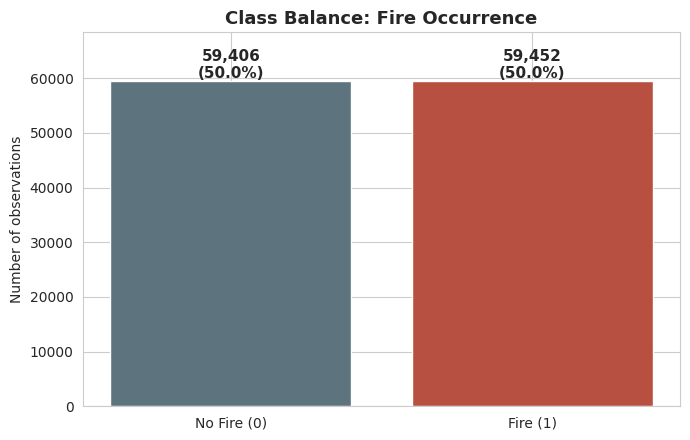

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["No Fire (0)", "Fire (1)"], counts.values,
              color=[COLOR_NOFIRE, COLOR_FIRE])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v,
            f"{v:,}\n({v/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Class Balance: Fire Occurrence", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of observations")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


**Finding 2 - Perfect class balance (50.0% / 50.0%):**

This has direct modeling implications for the Classification team:
- **No need for SMOTE, class weights or undersampling** - the dataset has already been balanced.
- **Accuracy is a valid metric** here (unlike most real-world fire datasets where fires are rare events).
- **Caveat for limitations slide:** this balance is artificial. Real satellite data has a heavy no-fire majority; our model's reported accuracy will not transfer directly to deployment.


### 3.2 Regression target: `frp` (Fire Radiative Power)

In [ ]:
print(df["frp"].describe())
print(f"\nSkewness: {df['frp'].skew():.2f}")
print(f"Rows with FRP == 0: {(df['frp'] == 0).sum()}")
print(f"Rows with FRP  > 0: {(df['frp'] > 0).sum():,}")


count    118858.000000
mean         18.657967
std          32.614357
min           0.000000
25%           4.770000
50%           9.670000
75%          18.480000
max        1056.150000
Name: frp, dtype: float64

Skewness: 6.18
Rows with FRP == 0: 61
Rows with FRP  > 0: 118,797


In [ ]:
print("FRP statistics grouped by occured:")
df.groupby("occured")["frp"].describe().round(2)


FRP statistics grouped by occured:


,count,mean,std,min,25%,50%,75%,max
occured,,,,,,,,
0.0,59406.0,9.21,18.89,0.0,2.63,4.92,8.95,839.94
1.0,59452.0,28.10,39.90,0.0,10.10,15.41,27.09,1056.15


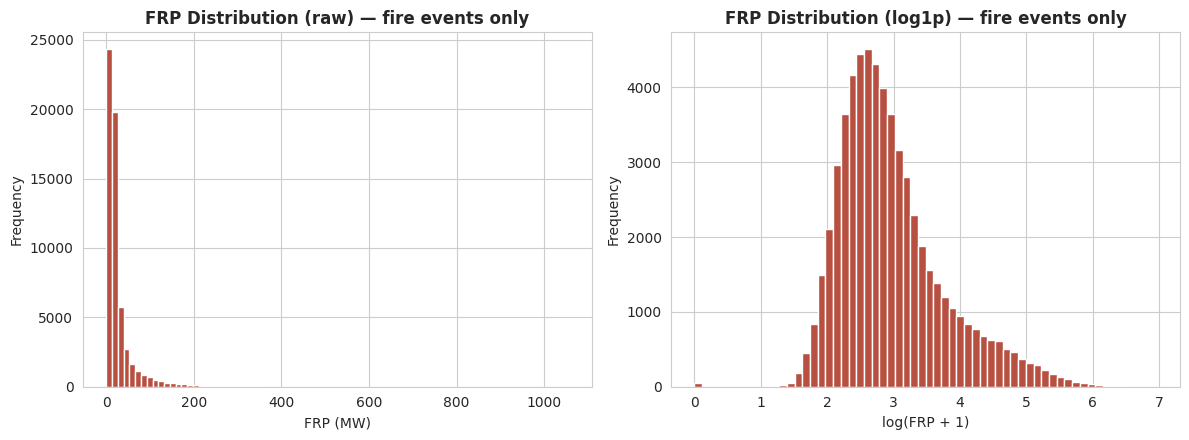

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fire_frp = df[df["occured"] == 1]["frp"]

axes[0].hist(fire_frp, bins=80, color=COLOR_FIRE, edgecolor="white")
axes[0].set_title("FRP Distribution (raw) — fire events only", fontweight="bold")
axes[0].set_xlabel("FRP (MW)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(fire_frp), bins=60, color=COLOR_FIRE, edgecolor="white")
axes[1].set_title("FRP Distribution (log1p) — fire events only", fontweight="bold")
axes[1].set_xlabel("log(FRP + 1)")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


**Finding 3 - FRP is heavily right-skewed (skew = 6.18):**

- Raw FRP ranges from 0 to 1,056 MW with most mass concentrated below 30 MW.
- A **log1p transformation** produces a near-normal distribution (right chart above).
- **Recommendation for the Regression team:** train on `log1p(frp)` and inverse-transform at inference. Without this, the model will be dominated by a small number of extreme outliers.

**Finding 4 - Unexpected FRP values in no-fire rows:**

The no-fire subset (`occured=0`) still has a non-zero mean FRP of ~9.2 MW. This suggests:
- FRP is a continuous satellite signal, not a clean "zero if no fire" quantity.
- The `occured` label appears to be threshold-based.
- **Recommendation:** Model 2 (Regression) should be trained only on fire-positive rows (`occured == 1`, n = 59,452) to predict intensity given that a fire exists. The pipeline then uses Model 1's probability as the gating signal.


## 4. Feature Analysis

We now look at the 15 predictor variables: 2 spatial (`lat`, `lon`), 1 temporal (`daynight_N`), and 12 weather-derived features.


### 4.1 Geographic distribution

In [ ]:
print(f"Latitude range:  {df['lat'].min():.2f} to {df['lat'].max():.2f}")
print(f"Longitude range: {df['lon'].min():.2f} to {df['lon'].max():.2f}")


Latitude range:  -51.78 to 71.23
Longitude range: -158.04 to 179.58


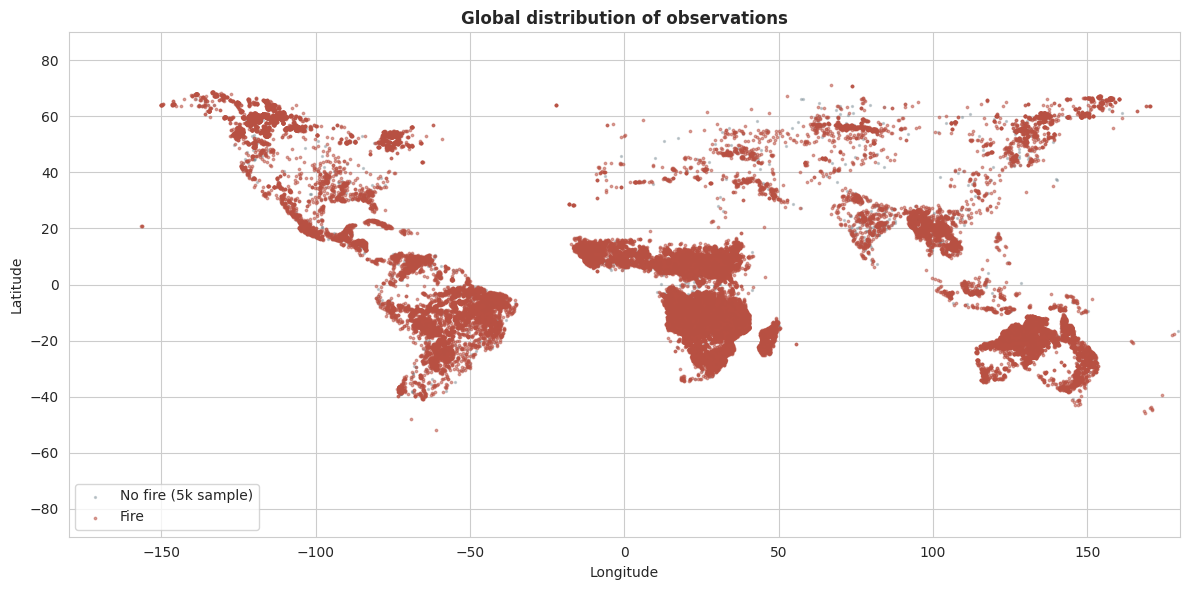

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

no_fire = df[df["occured"] == 0].sample(
    min(5000, (df["occured"] == 0).sum()), random_state=42)
fire = df[df["occured"] == 1]

ax.scatter(no_fire["lon"], no_fire["lat"], s=2, c=COLOR_NOFIRE,
           alpha=0.3, label="No fire (5k sample)")
ax.scatter(fire["lon"], fire["lat"], s=3, c=COLOR_FIRE,
           alpha=0.5, label="Fire")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global distribution of observations", fontweight="bold")
ax.legend(loc="lower left")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
plt.tight_layout()
plt.show()


**Finding 5 - Global coverage with known hotspots:**

Observations concentrate in sub-Saharan Africa, the Amazon basin, Southeast Asia, and Australia - all recognized global fire-prone regions.

### 4.2 Day vs. Night observations

In [ ]:
dn = df.groupby("daynight_N")["occured"].agg(["count", "sum", "mean"])
dn["fire_rate_pct"] = dn["mean"] * 100
print(dn)


             count      sum      mean  fire_rate_pct
daynight_N                                          
0.0         101073  56776.0  0.561733      56.173261
1.0          17785   2676.0  0.150464      15.046387


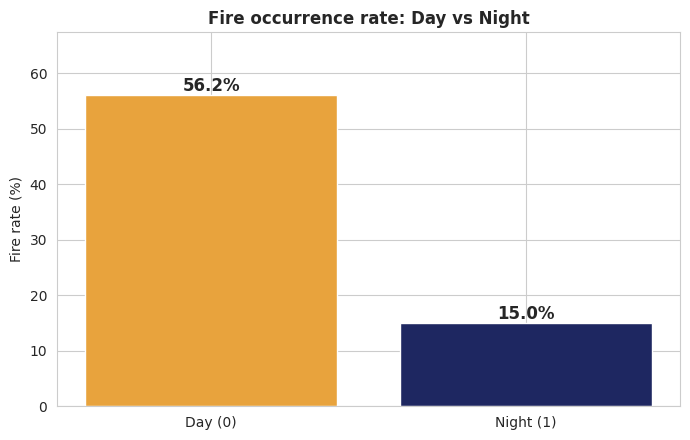

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["Day (0)", "Night (1)"], dn["fire_rate_pct"].values,
              color=[COLOR_DAY, COLOR_NIGHT])
for b, v in zip(bars, dn["fire_rate_pct"].values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_title("Fire occurrence rate: Day vs Night", fontweight="bold")
ax.set_ylabel("Fire rate (%)")
ax.set_ylim(0, dn["fire_rate_pct"].max() * 1.2)
plt.tight_layout()
plt.show()


**Finding 6 - `daynight_N` is the single strongest predictor:**

Day and night observations have dramatically different fire rates. This will be a top-ranked feature in the Classification model.

### 4.3 Feature distributions: fire vs. no-fire

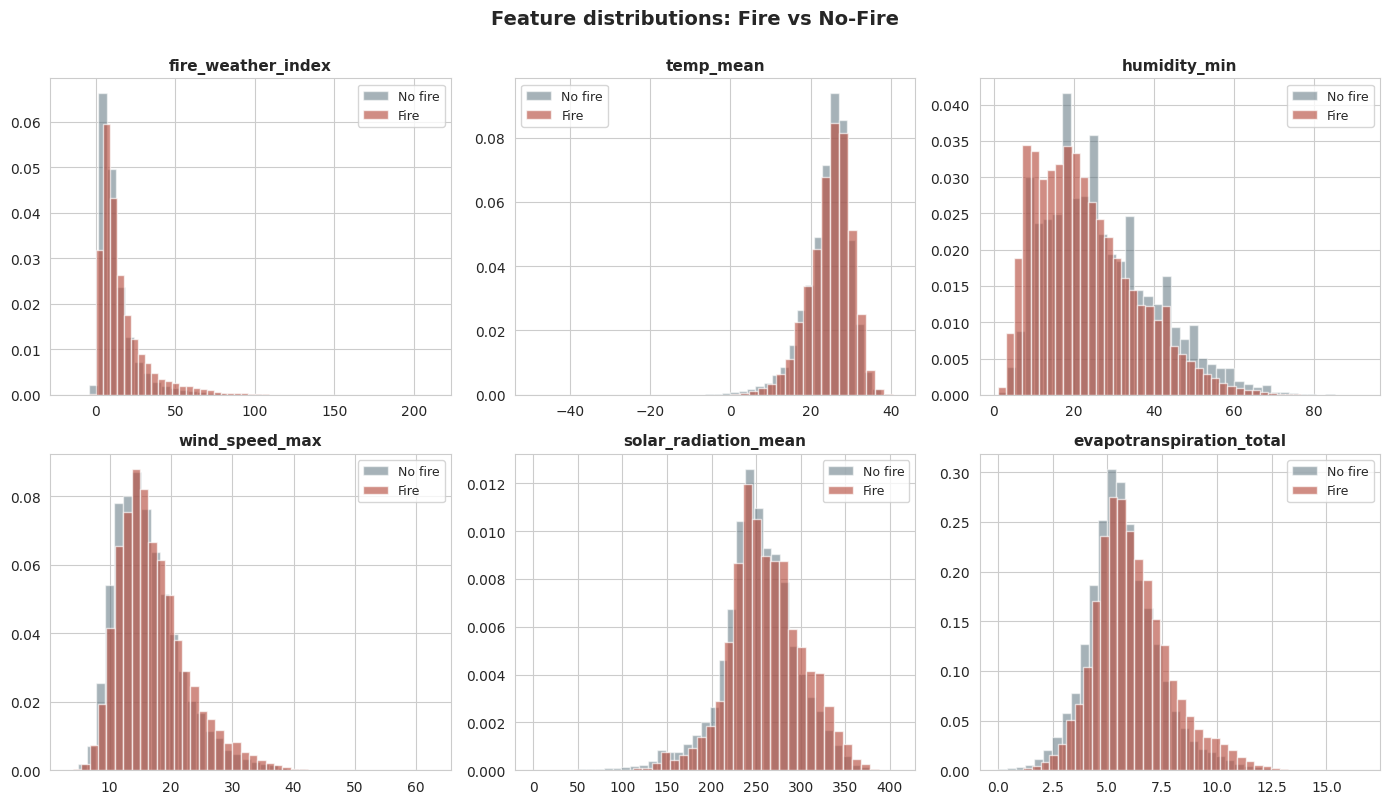

In [ ]:
features = ["fire_weather_index", "temp_mean", "humidity_min",
            "wind_speed_max", "solar_radiation_mean", "evapotranspiration_total"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), features):
    data_nofire = df[df["occured"] == 0][feat].dropna()
    data_fire = df[df["occured"] == 1][feat].dropna()
    ax.hist(data_nofire, bins=40, alpha=0.55, color=COLOR_NOFIRE,
            label="No fire", density=True)
    ax.hist(data_fire, bins=40, alpha=0.65, color=COLOR_FIRE,
            label="Fire", density=True)
    ax.set_title(feat, fontweight="bold", fontsize=11)
    ax.legend(fontsize=9)
plt.suptitle("Feature distributions: Fire vs No-Fire",
             fontweight="bold", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


In [ ]:
feat_cols = ["fire_weather_index", "temp_mean", "humidity_min",
             "wind_speed_max", "solar_radiation_mean", "cloud_cover_mean",
             "dewpoint_mean", "evapotranspiration_total", "temp_range"]
df.groupby("occured")[feat_cols].mean().round(2).T


occured,0.0,1.0
fire_weather_index,12.85,16.49
temp_mean,24.35,24.78
humidity_min,26.55,22.92
wind_speed_max,16.18,17.15
solar_radiation_mean,252.50,261.22
cloud_cover_mean,34.82,30.43
dewpoint_mean,9.76,8.11
evapotranspiration_total,5.72,6.17
temp_range,13.49,14.17


**Finding 7 - Separation is modest on individual features:**

Fire vs no-fire distributions overlap substantially for every single feature. Mean differences are directionally correct (fires occur at lower humidity, higher FWI, higher evapotranspiration) but small. This strongly suggests:

- **Linear models will underperform** - no single feature cleanly separates the classes.
- **Tree-based models (Random Forest, XGBoost)** should perform better because fire occurrence depends on non-linear interactions between features.


## 5. Correlation Analysis

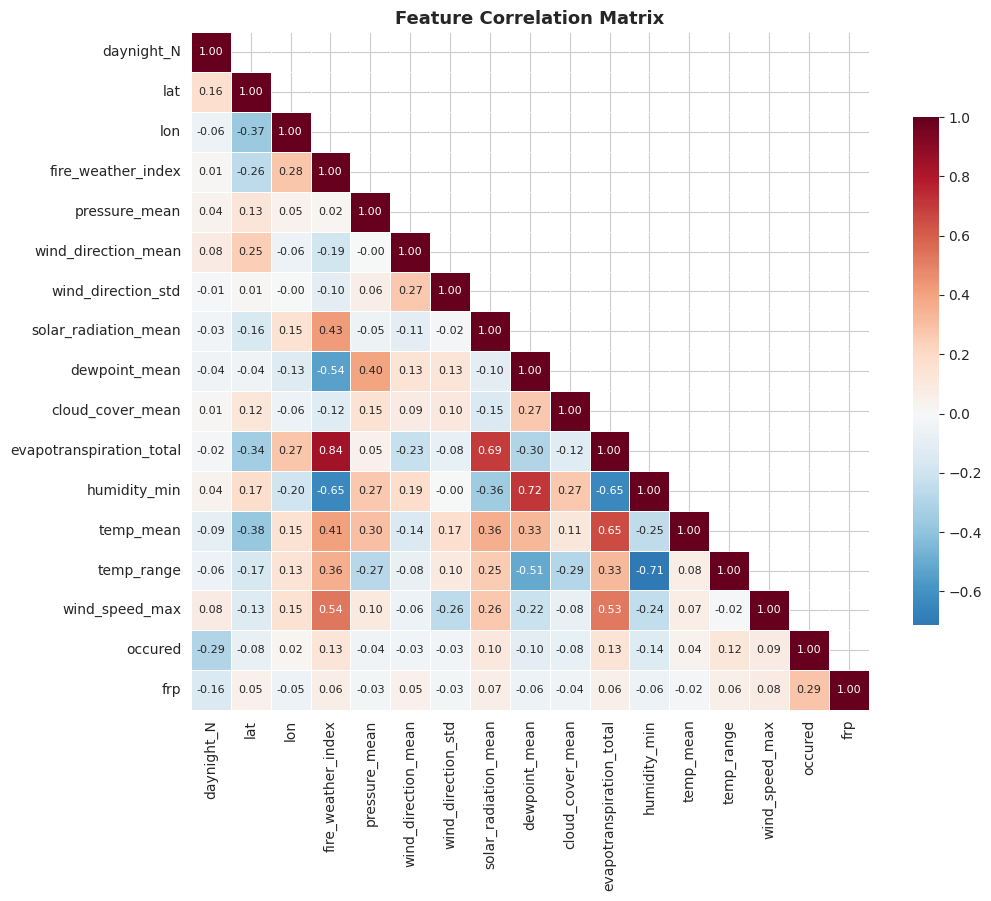

In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.75}, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


### 5.1 Correlation with `occured`

In [ ]:
corr_occured = (df.drop(columns=["frp"])
                   .corr(numeric_only=True)["occured"]
                   .sort_values(key=abs, ascending=False))
print(corr_occured)


occured                     1.000000
daynight_N                 -0.293408
humidity_min               -0.137935
evapotranspiration_total    0.129994
fire_weather_index          0.127266
temp_range                  0.119015
dewpoint_mean              -0.104371
solar_radiation_mean        0.103272
wind_speed_max              0.086547
cloud_cover_mean           -0.080189
lat                        -0.076389
pressure_mean              -0.042991
temp_mean                   0.039249
wind_direction_mean        -0.034882
wind_direction_std         -0.034235
lon                         0.016702
Name: occured, dtype: float64


### 5.2 Correlation with `frp` (fire-only subset)

In [ ]:
fire_df = df[df["occured"] == 1]
corr_frp = (fire_df.drop(columns=["occured"])
                   .corr(numeric_only=True)["frp"]
                   .sort_values(key=abs, ascending=False))
print(corr_frp)
print(f"\nFire-only subset size: {len(fire_df):,}")


frp                         1.000000
lat                         0.110704
wind_direction_mean         0.084827
lon                        -0.074405
wind_speed_max              0.071456
temp_mean                  -0.051276
solar_radiation_mean        0.046074
dewpoint_mean              -0.045342
fire_weather_index          0.032445
humidity_min               -0.026283
cloud_cover_mean           -0.024064
evapotranspiration_total    0.023724
temp_range                  0.020866
wind_direction_std         -0.018003
daynight_N                 -0.011848
pressure_mean              -0.010262
Name: frp, dtype: float64

Fire-only subset size: 59,452


**Finding 8 - Multicollinearity among weather features:**

Several weather features are heavily correlated with each other:
- `evapotranspiration_total` ↔ `fire_weather_index`: **+0.84** (near-duplicate signal)
- `humidity_min` ↔ `dewpoint_mean`: **+0.72**
- `humidity_min` ↔ `temp_range`: **−0.71**
- `humidity_min` ↔ `fire_weather_index`: **−0.65**

FWI is a composite index derived from temperature, humidity, wind, and precipitation - so this collinearity is expected. Recommendations:
- For **tree-based models** (likely what the team will use), multicollinearity is not a problem; models can be trained with the full feature set.
- For any **linear model** baseline, consider dropping `evapotranspiration_total` (redundant with FWI) or using Ridge regression.

**Finding 9 - FRP is hard to predict:**

Even within the fire-only subset, no feature correlates with FRP above 0.11. Fire intensity appears to be governed by factors not captured in this dataset (fuel load, vegetation type, terrain, wind gusts, ignition source). **Expect modest R² on Model 2.** This is a critical point for the limitations section.


## 6. Summary of Findings & Modeling Implications

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Zero missing values, zero duplicates | Real-world deployment will need data-quality handling |
| 2 | Perfect 50/50 class balance on `occured` | No SMOTE needed; accuracy is a valid metric |
| 3 | FRP is heavily right-skewed (skew = 6.18) | Regression team should log-transform the target |
| 4 | Non-zero FRP in no-fire rows | Train Model 2 only on fire-positive rows (n = 59,452) |
| 5 | Global coverage, known fire-prone regions | Used to project Model 3's weather-based clusters onto geography for interpretation |
| 6 | `daynight_N` has the strongest signal (−0.29 corr) | Expect it to be the top feature in Classification |
| 7 | Modest feature-level separation between classes | Prefer tree-based models over linear ones |
| 8 | Multicollinearity between FWI and weather features | Not an issue for trees; matters for linear baselines |
| 9 | All features correlate weakly with FRP (max 0.11) | Expect modest regression R²; flag in limitations |

---

### Decisions locked in by this EDA

1. **Shared preprocessed dataset** — all three models start from this cleaned file (no additional cleaning needed).
2. **Classification** (Model 1) - full dataset, no resampling, tree-based model preferred.
3. **Regression** (Model 2) - fire-positive subset only, log1p-transformed target.
4. **Clustering** (Model 3) - 9 meteorological features as inputs (`lat`, `lon` excluded); k = 4 chosen by domain reasoning (four-tier fire-danger convention). Cluster labels projected onto lat/lon for visualization only.